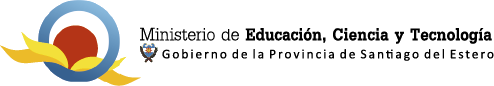


# Clasificación Multiclase (Multi-class Classification)


En este laboratorio, aprenderás las diferentes estrategias de clasificación multiclase e implementarás las mismas en un conjunto de datos del mundo real.


## **Objetivos**


Después de completar este laboratorio, podrás:



1. Comprender el uso de **one-hot encoding** para variables categóricas.
2. Implementar **regresión logística** para clasificación multiclase utilizando las estrategias **One-vs-All (OvA)** y **One-vs-One (OvO)**.
3. Evaluar el rendimiento del modelo utilizando las métricas adecuadas.



## Importar Librerías Necesarias



Primero, si alguna de las bibliotecas requeridas, no está disponible, puedes instalarla, de esta manera.



In [1]:
#!pip install numpy==2.2.0
#!pip install pandas==2.2.3
#!pip install scikit-learn==1.6.0
#!pip install matplotlib==3.9.3
#!pip install seaborn==0.13.2

Ahora, importa las bibliotecas necesarias para el procesamiento de datos, entrenamiento del modelo y evaluación.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

## Acerca del conjunto de datos
El conjunto de datos utilizado para este laboratorio es el conjunto de datos **"Predicción de Riesgo de Obesidad"**, disponible públicamente en la <a href="https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition">Biblioteca UCI</a> bajo la licencia <a href="https://creativecommons.org/licenses/by/4.0/legalcode">CCA 4.0</a>. El conjunto de datos tiene un total de 17 atributos junto con 2,111 muestras.

Los atributos del conjunto de datos se describen a continuación.



<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-7zrl">Nombre de la variable</th>
    <th class="tg-7zrl">Tipo</th>
    <th class="tg-7zrl">Descripción</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Gender</td>
    <td class="tg-7zrl">Categórica</td>
    <td class="tg-7zrl">Género</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Age</td>
    <td class="tg-7zrl">Continua</td>
    <td class="tg-7zrl">Edad</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Height</td>
    <td class="tg-7zrl">Continua</td>
    <td class="tg-7zrl">Altura</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Weight</td>
    <td class="tg-7zrl">Continua</td>
    <td class="tg-7zrl">Peso</td>
  </tr>
  <tr>
    <td class="tg-7zrl">family_history_with_overweight</td>
    <td class="tg-7zrl">Binaria</td>
    <td class="tg-7zrl">¿Algún miembro de la familia ha sufrido o sufre de sobrepeso?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">FAVC</td>
    <td class="tg-7zrl">Binaria</td>
    <td class="tg-7zrl">¿Comes alimentos con alto contenido calórico con frecuencia?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">FCVC</td>
    <td class="tg-7zrl">Entera</td>
    <td class="tg-7zrl">¿Sueles comer verduras en tus comidas?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">NCP</td>
    <td class="tg-7zrl">Continua</td>
    <td class="tg-7zrl">¿Cuántas comidas principales tienes al día?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">CAEC</td>
    <td class="tg-7zrl">Categórica</td>
    <td class="tg-7zrl">¿Comes algún tipo de alimento entre comidas?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">SMOKE</td>
    <td class="tg-7zrl">Binaria</td>
    <td class="tg-7zrl">¿Fumas?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">CH2O</td>
    <td class="tg-7zrl">Continua</td>
    <td class="tg-7zrl">¿Cuánta agua bebes al día?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">SCC</td>
    <td class="tg-7zrl">Binaria</td>
    <td class="tg-7zrl">¿Monitoreas las calorías que consumes al día?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">FAF</td>
    <td class="tg-7zrl">Continua</td>
    <td class="tg-7zrl">¿Con qué frecuencia realizas actividad física?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">TUE</td>
    <td class="tg-7zrl">Entera</td>
    <td class="tg-7zrl">¿Cuánto tiempo usas dispositivos tecnológicos como celular, videojuegos, televisión, computadora y otros?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">CALC</td>
    <td class="tg-7zrl">Categórica</td>
    <td class="tg-7zrl">¿Con qué frecuencia consumes alcohol?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">MTRANS</td>
    <td class="tg-7zrl">Categórica</td>
    <td class="tg-7zrl">¿Qué medio de transporte sueles usar?</td>
  </tr>
  <tr>
    <td class="tg-7zrl">NObeyesdad</td>
    <td class="tg-7zrl">Categórica</td>
    <td class="tg-7zrl">Nivel de obesidad</td>
  </tr>
</tbody></table>


### Cargar el conjunto de datos

Carga el conjunto de datos ejecutando la celda de código a continuación.


In [3]:
# Install gdown
!pip install -q gdown

# Download your specific file
!gdown https://drive.google.com/uc?id=1zVz_mCKKBFfQcBx5bUhOU9cvV5ec3KTw


Downloading...
From: https://drive.google.com/uc?id=1zVz_mCKKBFfQcBx5bUhOU9cvV5ec3KTw
To: /content/modulo2_dataset2_obesity_level_prediction_v2.csv
100% 275k/275k [00:00<00:00, 82.7MB/s]


In [4]:
data = pd.read_csv('modulo2_dataset2_obesity_level_prediction_v2.csv')
data.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [6]:
data.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

## Análisis Exploratorio de Datos



Visualiza la distribución de la variable objetivo para entender el balance de clases.


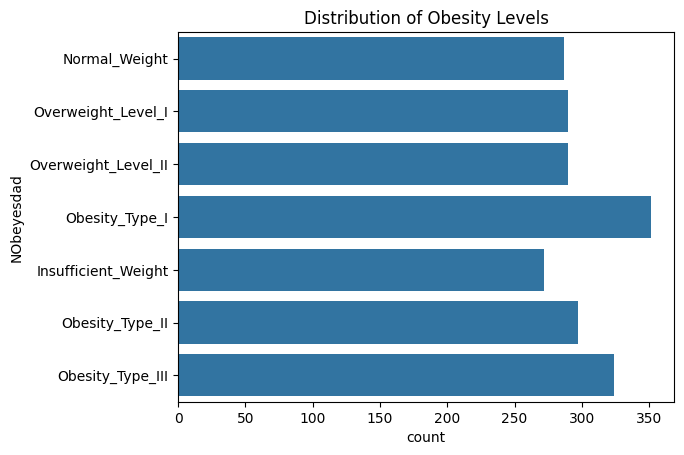

In [7]:
# Distribution of target variable
sns.countplot(y='NObeyesdad', data=data)
plt.title('Distribution of Obesity Levels')
plt.show()

Esto muestra que el conjunto de datos está bastante equilibrado y no requiere atención especial en términos de entrenamiento sesgado.


### Ejercicio 1
Verifica los valores nulos y muestra un resumen del conjunto de datos (usa los métodos `.isnull()`, `.info()` y `.describe()`).



In [8]:
print(data.isnull().sum())
print(data.info())
print(data.describe())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height             

Responde a estas preguntas:
1) ¿Hay variables con valores nulos?
2) Si no hay valores nulos, ¿es esto suficiente para asumir que los datos están “limpios”? Justifica.
3) ¿Cuántas variables son numéricas y cuántas categóricas?
4) ¿Qué variables requerirían transformación antes de entrenar un modelo de clasificación?
5) ¿Por qué es necesario aplicar One Hot Encoding a ciertas columnas? Da ejemplos concretos del dataset.
6) ¿Qué puedes decir sobre la escala de las variables numéricas (por ejemplo, edad, peso, altura)?
7) ¿Existen variables con rangos muy diferentes entre sí?
8) ¿Qué variables deberían escalarse y por qué?
9) ¿Qué técnica de escalado usarías (StandardScaler, MinMaxScaler, etc.)?

1. No hay valores nulos.
2. No porque pueden estar en un formato que no es adecuado para el análisis o puede haber valores anómalos.
3. Las variables numéricas son 8 y las categóricas 9.
4. Tanto variables categóricas como numéricas: La edad (int), FCVC (objet), NCP (int)
5. Es necesario aplicar One Hot Encoding a las columnas categóricas nominales para transformarlas en números para que el algoritmo lo entienda. Por ejemplo: columnas de género, historia familiar, medio de transporte, etc.
6. La edad varía entre 14 y 61; la altura varía entre 1,45 y 1,98; el peso varía entre 39 y 173. El modelo le daría mayor valor al peso si no utilizamos alguna técnica de escalado.
7. Si, hay variables que tienen un rango de mayor variación, como el peso.
8. Las variables numéricas continuas para evitar desvalances porque si estan en distintas unidades pueden dominar el modelo.
9. Depende la distribución de los datos, puede ser normalización o estandarización.  

## Preprocesamiento de los datos



### Escalado de características
Escala las características numéricas para estandarizar sus rangos y mejorar el rendimiento del modelo.



In [9]:
# Standardizing continuous numerical features
continuous_columns = data.select_dtypes(include=['float64']).columns.tolist()
print(continuous_columns, 'columnas continuas')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[continuous_columns])

# Converting to a DataFrame
scaled_df = pd.DataFrame(scaled_features, columns=scaler.get_feature_names_out(continuous_columns))
print(scaled_df.head(), 'datos escalados')

# Combining with the original dataset
scaled_data = pd.concat([data.drop(columns=continuous_columns), scaled_df], axis=1)
print(scaled_data.head(), 'datos escalados con el dataset original')

['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'] columnas continuas
        Age    Height    Weight      FCVC       NCP      CH2O       FAF  \
0 -0.522124 -0.875589 -0.862558 -0.785019  0.404153 -0.013073 -1.188039   
1 -0.522124 -1.947599 -1.168077  1.088342  0.404153  1.618759  2.339750   
2 -0.206889  1.054029 -0.366090 -0.785019  0.404153 -0.013073  1.163820   
3  0.423582  1.054029  0.015808  1.088342  0.404153 -0.013073  1.163820   
4 -0.364507  0.839627  0.122740 -0.785019 -2.167023 -0.013073 -1.188039   

        TUE  
0  0.561997  
1 -1.080625  
2  0.561997  
3 -1.080625  
4 -1.080625   datos escalados
   Gender family_history_with_overweight FAVC       CAEC SMOKE  SCC  \
0  Female                            yes   no  Sometimes    no   no   
1  Female                            yes   no  Sometimes   yes  yes   
2    Male                            yes   no  Sometimes    no   no   
3    Male                             no   no  Sometimes    no   no   
4    Male 

La estandarización de los datos es importante para definir mejor los límites de decisión entre clases, asegurando que las variaciones de las características estén en escalas similares. Los datos ahora están listos para ser utilizados en el entrenamiento y la prueba.



### Codificación one-hot
Convierte variables categóricas en formato numérico utilizando codificación one-hot.



In [10]:
# Identifying categorical columns
categorical_columns = scaled_data.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('NObeyesdad')  # Exclude target column
print(categorical_columns, 'columnas categóricas')

# Applying one-hot encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(scaled_data[categorical_columns])


# Converting to a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))

# Combining with the original dataset
prepped_data = pd.concat([scaled_data.drop(columns=categorical_columns), encoded_df], axis=1)
prepped_data.head()

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'] columnas categóricas


,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Normal_Weight,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,Normal_Weight,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Normal_Weight,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Overweight_Level_I,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Overweight_Level_II,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


Observarás que todas las variables categóricas han sido modificadas a características codificadas mediante one-hot. Esto incrementa el número total de campos a 24.



### Codificar la variable objetivo



In [11]:
# Encoding the target variable
prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes
prepped_data.head(10)

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,1,0.738817,-0.875589,-1.282647,-0.785019,0.404153,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,1,-0.206889,-2.162001,-1.206267,1.088342,0.404153,-0.013073,-0.012109,-1.080625,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7,1,-0.364507,-0.661187,-1.282647,-0.785019,0.404153,-0.013073,2.339750,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8,1,-0.049271,0.839627,-0.862558,1.088342,0.404153,-0.013073,-0.012109,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9,1,-0.364507,0.196421,-0.709799,-0.785019,0.404153,-0.013073,-0.012109,0.561997,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### Separar los datos de entrada y objetivo


In [12]:
# Preparing final dataset
X = prepped_data.drop('NObeyesdad', axis=1)
y = prepped_data['NObeyesdad']

## Entrenamiento y evaluación del modelo



### Dividiendo el conjunto de datos
Divide los datos en subconjuntos de entrenamiento y prueba.


In [13]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Regresión Logística con One-vs-All
En el enfoque One-vs-All:

* El algoritmo entrena un clasificador binario para cada clase.
* Cada clasificador aprende a distinguir una sola clase de todas las demás combinadas.
* Si hay k clases, se entrenan k clasificadores.
* Durante la predicción, el algoritmo evalúa todos los clasificadores en cada entrada y selecciona la clase con la puntuación de confianza más alta como la clase predicha.

#### Ventajas:
* Más simple y eficiente en términos de la cantidad de clasificadores (k).
* Más fácil de implementar para algoritmos que proporcionan puntuaciones de confianza de forma natural (por ejemplo, regresión logística, SVM).

#### Desventajas:
* Los clasificadores pueden tener dificultades con el desbalanceo de clases, ya que cada clasificador binario debe distinguir entre una clase y el resto.
* Requiere que el clasificador funcione bien incluso con conjuntos de datos altamente desbalanceados, ya que el grupo "todos" generalmente contiene más muestras que la clase "uno".


Entrenar un modelo de regresión logística utilizando la estrategia **Uno contra Todos** y evaluar su rendimiento.



In [14]:
# Training logistic regression model using One-vs-All (default)
model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
model_ova.fit(X_train, y_train)

LogisticRegression(max_iter=1000, multi_class='ovr')

Ahora puedes evaluar la precisión del modelo entrenado como una medida de su rendimiento sobre datos de prueba no vistos.


In [15]:
# Predictions
y_pred_ova = model_ova.predict(X_test)

# Evaluation metrics for OvA
print("One-vs-All (OvA) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ova),2)}%")

One-vs-All (OvA) Strategy
Accuracy: 76.12%


### Regresión Logística con OvO

En el enfoque **Uno contra Uno (OvO)**:
* El algoritmo entrena un clasificador binario para cada par de clases en el conjunto de datos.
* Si hay k clases, esto resulta en $k(k-1)/2$ clasificadores.
* Cada clasificador se entrena para distinguir entre dos clases específicas, ignorando el resto.
* Durante la predicción, se utilizan todos los clasificadores, y un mecanismo de "votación" decide la clase final seleccionando la clase que gana la mayoría de las comparaciones por pares.

#### Ventajas:
* Es adecuado para algoritmos que son costosos computacionalmente al entrenar sobre muchas muestras, ya que cada clasificador binario trabaja con un conjunto de datos más pequeño (solo muestras de dos clases).
* Puede ser más preciso en algunos casos, ya que los clasificadores se enfocan en distinguir entre dos clases específicas a la vez.

#### Desventajas:
* Costoso computacionalmente para conjuntos de datos con un gran número de clases debido a la gran cantidad de clasificadores necesarios.
* Puede llevar a predicciones ambiguas si la votación resulta en un empate.


Entrenar un modelo de regresión logística utilizando la estrategia Uno contra Uno (OvO) y evaluar su rendimiento.


In [16]:
# Training logistic regression model using One-vs-One
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000))
model_ovo.fit(X_train, y_train)

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000))

Evalúa la precisión del modelo entrenado como una medida de su rendimiento sobre datos de prueba no vistos.



In [17]:
# Predictions
y_pred_ovo = model_ovo.predict(X_test)

# Evaluation metrics for OvO
print("One-vs-One (OvO) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ovo),2)}%")

One-vs-One (OvO) Strategy
Accuracy: 92.2%


Ahora evaluamos el desempeño del modelo utilizando la matriz de confusión y métricas como exactitud, precisión, recall y F1-score.

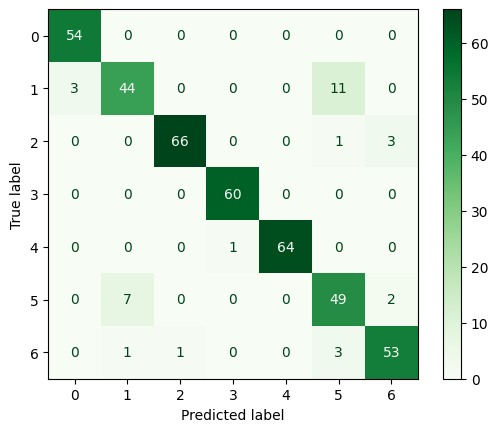

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_ovo)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_ovo, average='weighted')
recall = recall_score(y_test, y_pred_ovo, average='weighted')
f1 = f1_score(y_test, y_pred_ovo, average='weighted')

print("One-vs-One (OvO) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ovo),2)}%")
print(f"Precision: {np.round(precision, 3)}")
print(f"Recall: {np.round(recall, 3)}")
print(f"F1-score: {np.round(f1, 3)}")

One-vs-One (OvO) Strategy
Accuracy: 92.2%
Precision: 0.923
Recall: 0.922
F1-score: 0.922


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_ovo))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        54
           1       0.85      0.76      0.80        58
           2       0.99      0.94      0.96        70
           3       0.98      1.00      0.99        60
           4       1.00      0.98      0.99        65
           5       0.77      0.84      0.80        58
           6       0.91      0.91      0.91        58

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.92      0.92      0.92       423



### Ejercicios


Q1. Experimenta con diferentes tamaños de prueba en el método `train_test_split` (por ejemplo, 0.1, 0.3) y observa el impacto en el rendimiento del modelo.



In [21]:
for test_size_ratio in [0.1, 0.3]:
    # División de los datos en entrenamiento y test
    X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(X, y, test_size=test_size_ratio, random_state=42, stratify=y)

    # Entrenamiento del modelo
    model_ova.fit(X_train_loop, y_train_loop)

    # Predicción
    y_pred = model_ova.predict(X_test_loop)

    print(f"Test Size: {test_size_ratio}")
    print("Accuracy:", accuracy_score(y_test_loop, y_pred))

Test Size: 0.1
Accuracy: 0.7594339622641509
Test Size: 0.3
Accuracy: 0.749211356466877


Q2. Traza un gráfico de barras de la importancia de las características utilizando los coeficientes del modelo de regresión logística **One vs All**. También intenta hacerlo para el modelo **One vs One**.



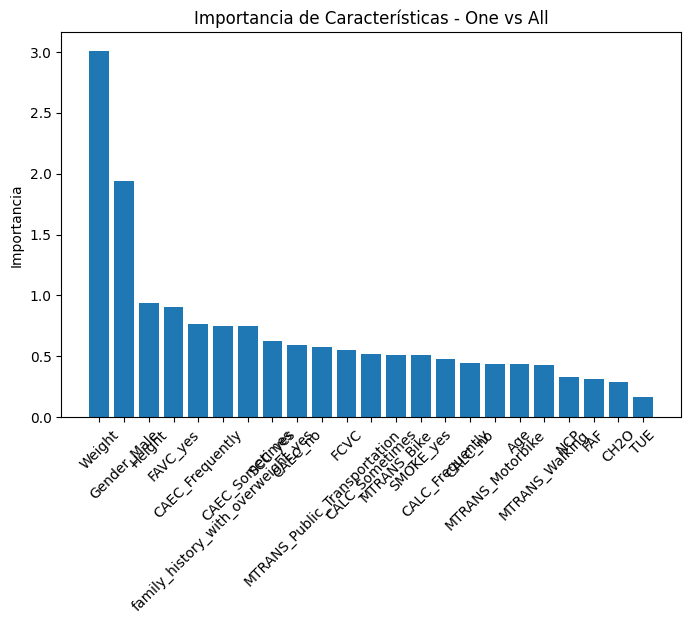

In [22]:
# ONE VS ALL
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# promedio del valor absoluto de los coeficientes
importance_ova = np.mean(np.abs(model_ova.coef_), axis=0)

# nombres de variables
features = X.columns

# dataframe
coef_df_ova = pd.DataFrame({
    'Característica': features,
    'Importancia': importance_ova
})

# ordenar
coef_df_ova = coef_df_ova.sort_values(by='Importancia', ascending=False)

# gráfico
plt.figure(figsize=(8,5))
plt.bar(coef_df_ova['Característica'],
        coef_df_ova['Importancia'])

plt.xticks(rotation=45)
plt.title('Importancia de Características - One vs All')
plt.ylabel('Importancia')
plt.show()

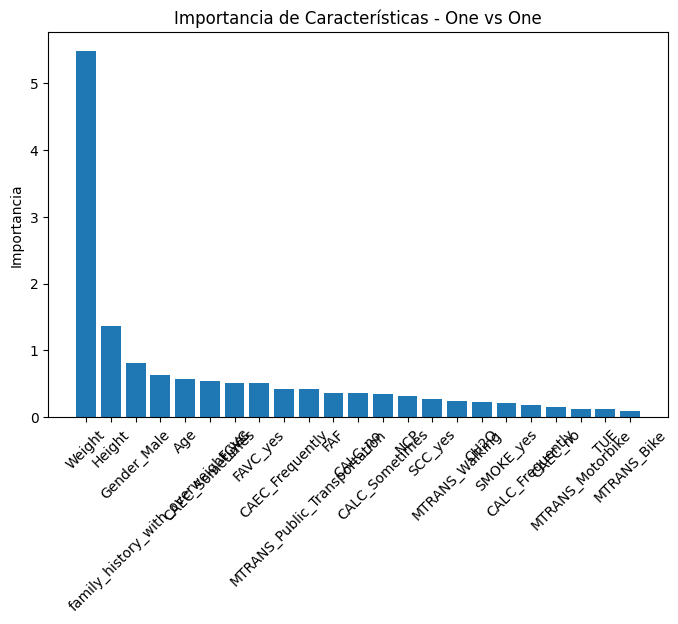

In [23]:
#ONE VS ONE
importance_ovo = np.mean(
    [np.abs(est.coef_[0]) for est in model_ovo.estimators_],
    axis=0
)

coef_df_ovo = pd.DataFrame({
    'Característica': features,
    'Importancia': importance_ovo
})

coef_df_ovo = coef_df_ovo.sort_values(
    by='Importancia',
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(coef_df_ovo['Característica'],
        coef_df_ovo['Importancia'])

plt.xticks(rotation=45)
plt.title('Importancia de Características - One vs One')
plt.ylabel('Importancia')
plt.show()

<details><summary>Haz clic aquí para ver la solución</summary>


```python
# Feature importance
feature_importance = np.mean(np.abs(model_ova.coef_), axis=0)
plt.barh(X.columns, feature_importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()
```

For One vs One, change `model_ova` to `model_ovo` in the code above.
</details>


Q3. Escribe una función `obesity_risk_pipeline` para automatizar todo el proceso: <br>
<ol>
<li> Cargar y preprocesar los datos </li>
<li> Entrenar el modelo </li>
<li> Evaluar el modelo </li>
</ol>
La función debe aceptar la ruta del archivo y el tamaño del conjunto de prueba como argumentos de entrada.



In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def obesity_risk_pipeline(data_path, test_size=0.2):
    # Load data
    data = pd.read_csv(data_path)

    # Standardizing continuous numerical features
    scaler = StandardScaler()
    numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Eliminamos la variable objetivo si está entre las numéricas
    if 'NObeyesdad' in numerical_cols:
        numerical_cols.remove('NObeyesdad')

    scaled_features = scaler.fit_transform(data[numerical_cols])

    # Converting to a DataFrame
    scaled_df = pd.DataFrame(scaled_features, columns=numerical_cols)

    # Combining with the original dataset
    data = data.drop(columns=numerical_cols)
    data = pd.concat([data.reset_index(drop=True),
                      scaled_df.reset_index(drop=True)], axis=1)

    # Identifying categorical columns
    categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

    # Exclude target column if it's still in categorical_cols
    if 'NObeyesdad' in categorical_cols:
        categorical_cols.remove('NObeyesdad')

    # Applying one-hot encoding
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_features = encoder.fit_transform(data[categorical_cols])

    # Converting to a DataFrame
    encoded_df = pd.DataFrame(
        encoded_features,
        columns=encoder.get_feature_names_out(categorical_cols)
    )

    # Combining with the original dataset
    data = data.drop(columns=categorical_cols)
    data = pd.concat([data.reset_index(drop=True),
                      encoded_df.reset_index(drop=True)], axis=1)

    # Encoding the target variable
    le = LabelEncoder()
    data['NObeyesdad'] = le.fit_transform(data['NObeyesdad'])

    # Preparing final dataset
    X = data.drop('NObeyesdad', axis=1)
    y = data['NObeyesdad']

    # Splitting data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    # Training and evaluation
    model = LogisticRegression(multi_class='multinomial', max_iter=1000)
    model.fit(X_train, y_train) # Fit the model
    y_pred = model.predict(X_test) # Make predictions

    print("Accuracy:", accuracy_score(y_test, y_pred))

# Example usage (assuming the file is in the current directory)
file_path = 'modulo2_dataset2_obesity_level_prediction_v2.csv'
obesity_risk_pipeline(file_path, test_size=0.2)

Accuracy: 0.8747044917257684


### ¡Felicidades! ¡Estás listo para continuar con tu próxima lección!
